In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_data=pd.read_csv(r"C:\Users\dharm\Documents\Nareshit\data files\Visadataset.csv")
visa_data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [3]:
num=visa_data.select_dtypes(exclude='object').columns
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [4]:
cat=visa_data.select_dtypes(include='object').columns
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

- we only did a categorical column analysis
- we did a numerical column analysis
- it is time to do multiple column analysis
- lets assume continent vs casestatus
- we know different applicants from different continents
- in that some of visa are certified ,some are denied
- so visa certified and denied overall info available in case_status


In [5]:
visa_data['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [6]:
visa_data['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [7]:
con1=visa_data['continent']=='Asia'
con2=visa_data['case_status']=='Certified'
certified_count=np.sum(con1  &  con2)

con3=visa_data['case_status']=='Denied'
denied_count=np.sum(con1 & con3)
certified_count,denied_count

(np.int64(11012), np.int64(5849))

In [6]:
visa_data['continent'].value_counts().keys()

Index(['Asia', 'Europe', 'North America', 'South America', 'Africa',
       'Oceania'],
      dtype='object', name='continent')

In [8]:
keys=visa_data['continent'].value_counts().keys()
clist=[]
dlist=[]
for i in keys:
    con1=visa_data['continent']==i
    con2=visa_data['case_status']=='Certified'
    certi_count=np.sum(con1 & con2)
    print
    clist.append(certi_count)

    con3=visa_data['case_status']=='Denied'
    deni_count=np.sum(con1  & con3)
    dlist.append(deni_count)

pd.DataFrame(zip(clist,dlist),columns=['Certified','Denied'],index=keys)


,Certified,Denied
continent,,
Asia,11012,5849
Europe,2957,775
North America,2037,1255
South America,493,359
Africa,397,154
Oceania,122,70


**cross tab**

In [ ]:
pd.crosstab(index,
    columns,
    values=None,
    rownames=None,
    colnames=None,
    aggfunc=None,
    margins: 'bool' = False,
    margins_name: 'Hashable' = 'All',
    dropna: 'bool' = True,
    normalize: "bool | Literal[0, 1, 'all', 'index', 'columns']" = False)

In [9]:
# which column i want to choose as index
# which column i have to use as columns
col1=visa_data['case_status']
col2=visa_data['continent']
pd.crosstab(col2,col1)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [11]:
col1=visa_data['case_status']
col2=visa_data['continent']

col3=visa_data['education_of_employee']
pd.crosstab(col1,col2)

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


In [13]:
col1=visa_data['case_status']
col2=visa_data['continent']

col3=visa_data['education_of_employee']
pd.crosstab(col2,[col1,col3])

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

In [14]:
col1=visa_data['case_status']
col2=visa_data['continent']
col3=visa_data['education_of_employee']
pd.crosstab(col3,[col2,col1])

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

**scatter-plot**

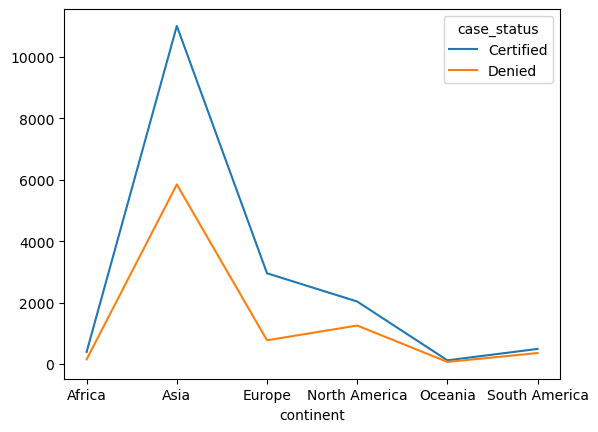

In [10]:
col1=visa_data['case_status']
col2=visa_data['continent']
r1=pd.crosstab(col2,col1)
r1.plot()
plt.show()

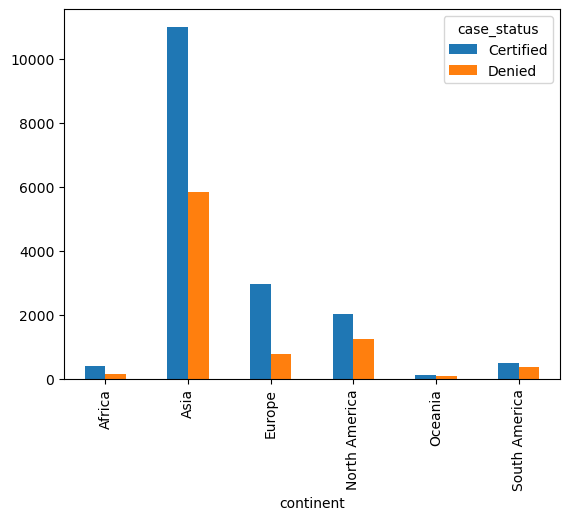

In [11]:
col1=visa_data['case_status']
col2=visa_data['continent']
r1=pd.crosstab(col2,col1)
r1.plot(kind='bar')
plt.show()

- categorical:**frequency table bar chart pie**
- numerical:**histogram**
- categorical vs categorical: **pd.crosstab()**
- numerical vs numerical :**scatterplots,cova, corre**

**numerical numerical**

**scatter chart**
- it is a graph representation between two numerical columns
- it also gives the relationship statius between two columns
    - positive or negative or no relation

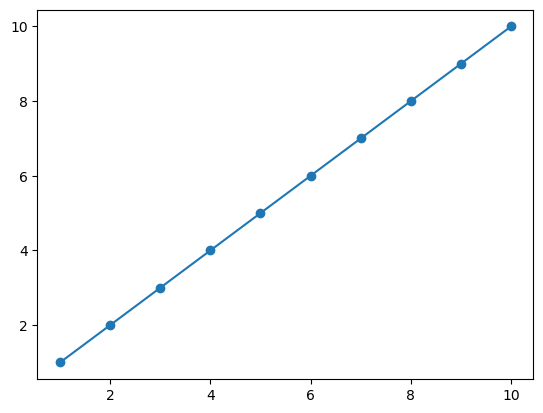

In [12]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

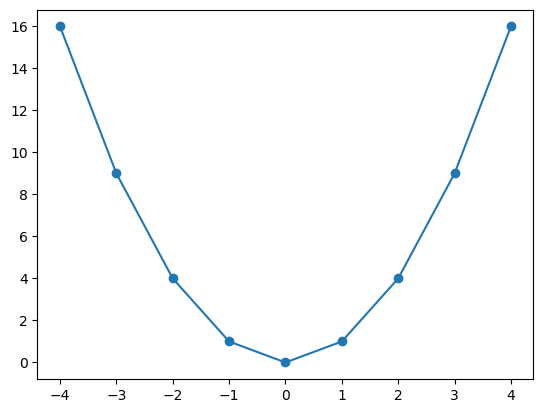

In [13]:
x=range(-4,5)
y=np.square(x)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

In [21]:
y

array([16,  9,  4,  1,  0,  1,  4,  9, 16])

In [24]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

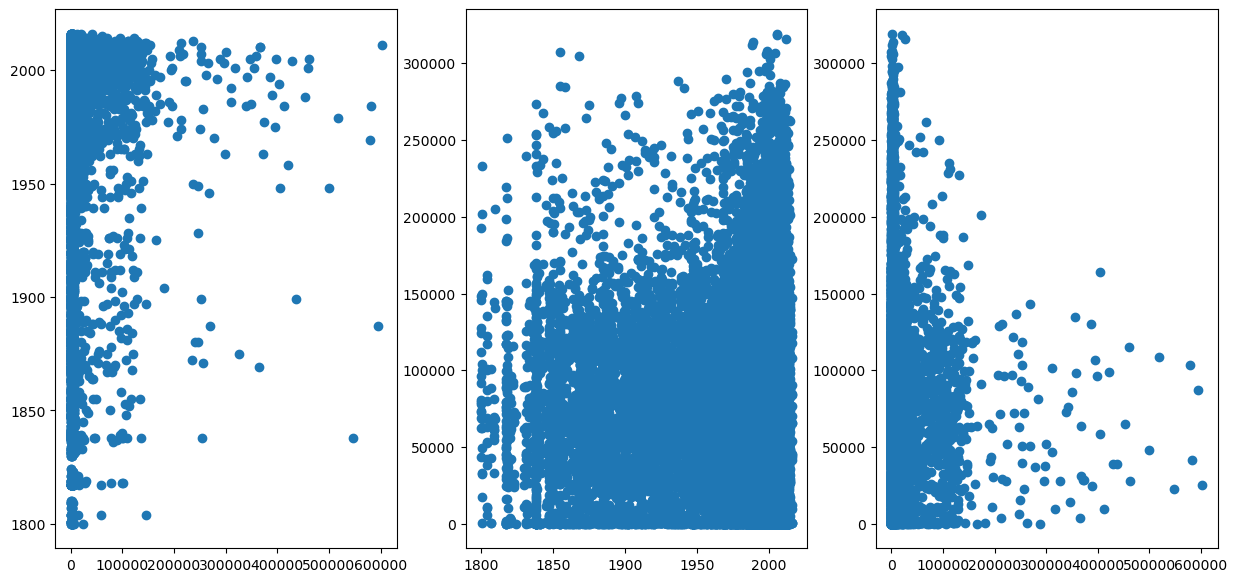

In [29]:

col1=visa_data['no_of_employees']
col2=visa_data['yr_of_estab']
col3=visa_data['prevailing_wage']
plt.figure(figsize=(15,7))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)
plt.show()

- we have draw the scatter plots for numerical column
- by seeing above plots we are not able to identify the relationship accurately
- to get more confidence we will go to corelaton matrix
- correlaton -1 to +1


In [14]:
visa_data.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


**all the columns are independent to each other**

In [ ]:
## in your datafiles :winequality
# read the df
# perform the correlation matrix
# do your analysis yourself immediately which columns has high +ve -ve relation

In [15]:
wine_data=pd.read_csv(r"C:\Users\dharm\Documents\Nareshit\data files\winequality_red.csv")

In [16]:
wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [19]:
wine_data.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


**heatmap**(seaborne)
- so far whatever the plots we did the same we can implement by using seaborn
- bar, countplots,histogram,distibution,boxplot

<Axes: >

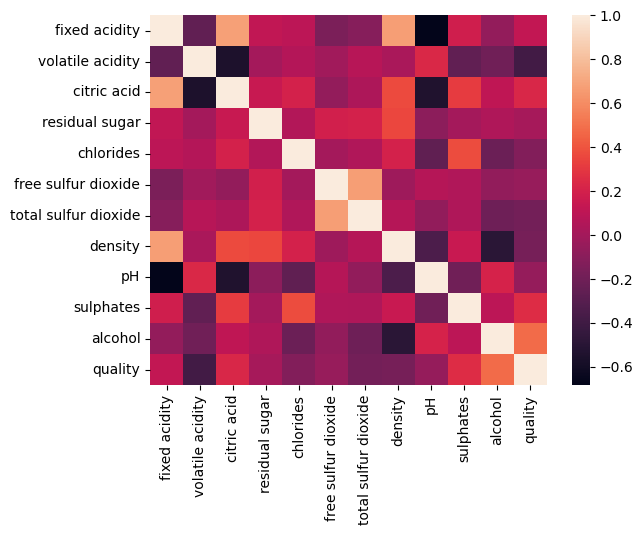

In [24]:
sns.heatmap(wine_data.corr())

<Axes: >

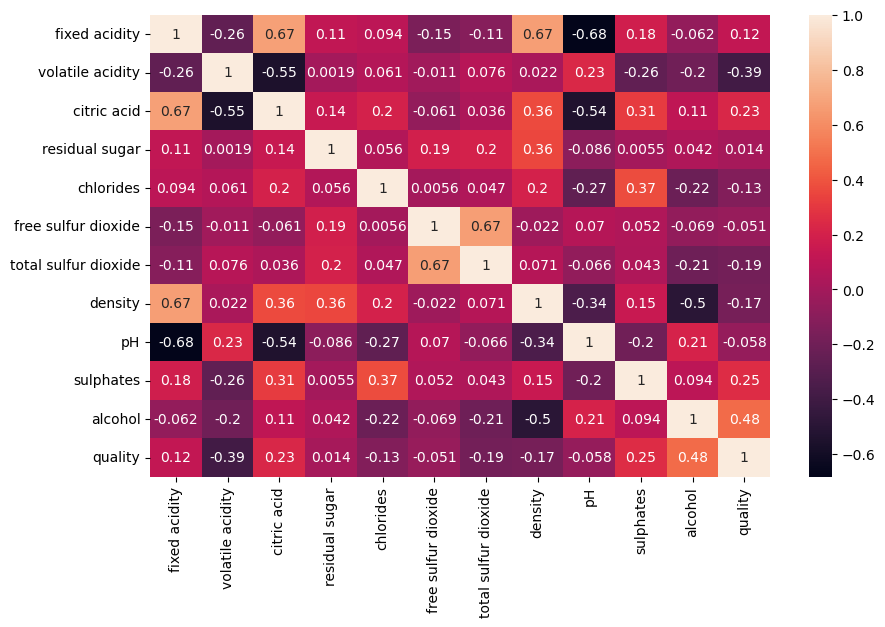

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(wine_data.corr(),annot=True)